In [39]:
from pathlib import Path 
import os 
import sys
import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math

In [40]:
def manual_filtering(df_dict, 
                     bounds, 
                     columns_to_keep, 
                     celltype_fraction, 
                     margin_frac_prop,
                     margin_frac_bounds, 
                     protocol_cols):
    
    # Filtered data frame 
    df_dict_filtered = {}
    df_dict_annotated = {}
    
    # Iterate over cell types 
    for cell_type in df_dict:
        # Collect cell type dictionary and sort by proportion 
        cell_type_revert_safe_string = cell_type.replace(":", "/")
        df_ct = df_dict[cell_type].copy()
        df_ct = df_ct.sort_values(by=f"{cell_type_revert_safe_string}_prop", ascending=False)
        
        # Subset data frame 
        columns_to_keep_ct = columns_to_keep + [f"{cell_type_revert_safe_string}_prop"]
        df_ct = df_ct.loc[:, columns_to_keep_ct]
        df_ct["filtering_step"] = "pass" 

        # Filter by fraction
        idx_lower = df_ct[f"{cell_type_revert_safe_string}_prop"] < (
            celltype_fraction[cell_type_revert_safe_string] - 
            celltype_fraction[cell_type_revert_safe_string] * margin_frac_prop
        )
        df_ct.loc[idx_lower & (df_ct["filtering_step"] == "pass"), 
                  "filtering_step"] = "proportion_filter"

        # Oxygen and days filtering 
        idx_pass_oxygen_days = np.logical_and(df_ct["o2_[%]"] > 5, 
                                             df_ct["o2_[%]"] < 25)
        idx_pass_oxygen_days = np.logical_and(idx_pass_oxygen_days, 
                                             df_ct["days_of_culture"] > 12)
        idx_pass_oxygen_days = np.logical_and(idx_pass_oxygen_days, 
                                             df_ct["days_of_culture"] < 20)
        df_ct.loc[~idx_pass_oxygen_days & (df_ct["filtering_step"] == "pass"), 
                  "filtering_step"] = "oxygen_days"

        # Bounds 
        for param in protocol_cols:
            idx_bounds = np.logical_and(
                df_ct[param] >= (bounds[param][0] - bounds[param][0] * margin_frac_bounds), 
                df_ct[param] <= (bounds[param][1] + bounds[param][1] * margin_frac_bounds)
            )
            df_ct.loc[~idx_bounds & (df_ct["filtering_step"] == "pass"), 
                      "filtering_step"] = f"bounds_{param}"

        # Filtered dataset
        df_dict_filtered[cell_type] = df_ct[df_ct.filtering_step == "pass"]
        df_dict_annotated[cell_type] = df_ct
        
    return df_dict_filtered, df_dict_annotated

In [41]:
import yaml

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
print(protocol_cols)

['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']


In [42]:
ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

Get real ranges 

In [43]:
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds

{'gm-csf_[ng_ml]': (0.0, 10.0),
 'tpo_[ng_ml]': (0.0, 2.5),
 'um171_[nm]': (0.0, 1120.0),
 'um729_[µm]': (0.0, 1120.0),
 'sr1_[nm]': (0.0, 750.0),
 'scf_[ng_ml]': (0.0, 50.0),
 'butyzamide_[nm]': (0.0, 100.0),
 'retinoic_acid_[µm]': (0.0, 25.0),
 'ldl_[ng_ml]': (0.0, 50.0),
 'il3_[ng_ml]': (0.0, 20.0),
 'o2_[%]': (10.0, 20.0),
 'days_of_culture': (12.0, 18.0)}

In [58]:
# celltype_fraction = {
#     "MgkPro": 0.42,
#     "HSCs": 0.21,
#     "EryPro": 0.42,
#     "GMP-Neutro/CD16-Mono": 0.17,
#     "CyclingProgenitor*": 0.30,
#     "EosBasoMastPre": 0.80,
#     "Early_Pro-B": 0.20,
#     "Pro-B": 0.20,
#     "CD14-Mono": 0.24,
#     "DCs-CD14": 0.20
# }

celltype_fraction = {
    "MgkPro": 0.20,
    "HSCs": 0.20,
    "EryPro": 0.20,
    "GMP-Neutro/CD16-Mono": 0.20,
    "CyclingProgenitor*": 0.20,
    "EosBasoMastPre": 0.20,
    "Early_Pro-B": 0.20,
    "Pro-B": 0.20,
    "CD14-Mono": 0.20,
    "DCs-CD14": 0.20
}


columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "loss", 
    'target_ct_loss_std',
    'ct_prop_total_variance',
    'exploitation_score'
]

### Loop over solutions 

In [45]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data")
paths = os.listdir(path_to_results)

In [46]:
cell_types = ["CD14-Mono",
              "CyclingProgenitor*",
              "DCs-CD14",
              "Early_Pro-B", 
              "EosBasoMastPre", 
              "EryPro",
              "GMP-Neutro:CD16-Mono",
              "HSCs",
              "MgkPro",
              "Pro-B"]

In [47]:
pure_cell_type_solution_dict = {cell_type: [] for cell_type in cell_types}

for experiment_folder in tqdm(paths):
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        for cell_type in os.listdir(cell_type_file_paths):
            config_exp_folders = cell_type_file_paths / cell_type
            for config_exp_folder in os.listdir(config_exp_folders):
                if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                    uncertainty_path = config_exp_folders / config_exp_folder / "uncertainty_annotation" / "candidates_with_uncertainties.csv"
                    if uncertainty_path.exists():
                        candidate_with_uncertainty_df = pd.read_csv(uncertainty_path)
                        candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                        pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

# for experiment_folder in tqdm(paths):
#     if "pure" in experiment_folder:
#         cell_type_file_paths = path_to_results / experiment_folder
#         for cell_type in os.listdir(cell_type_file_paths):
#             config_exp_folders = path_to_results / experiment_folder / cell_type
#             for config_exp_folder in os.listdir(config_exp_folders):
#                 if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
#                     candidate_with_uncertainty_df = pd.read_csv(config_exp_folders / config_exp_folder / "candidates.csv")
#                     candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
#                     pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

100%|██████████| 18/18 [01:44<00:00,  5.80s/it]


In [60]:
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key,val in pure_cell_type_solution_dict.items()
}

In [61]:
for col in pure_cell_type_solution_dict_concat["HSCs"].columns:
    print(col)

Unnamed: 0
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14-Mono_prop
CD49c-Myeloid_prop
CyclingProgenitor*_prop
DCs-CD14_prop
EarlyGMP_prop
Early_Pro-B_prop
EosBasoMastPre_prop
EosBasoMastPre_2_prop
EryPro_prop
GMP-Cycle_prop
GMP-Neutro_prop
GMP-Neutro/CD16-Mono_prop
HSCs_prop
MEP_prop
MLP_prop
MPP_prop
MgkPro_prop
Pro-B_prop
pDCs/cDCs_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_rep
cfg:annotation:scatter_obsm_key
cfg:annotat

### Filter values

In [62]:
filtered_df, annotated_df = manual_filtering(
    pure_cell_type_solution_dict_concat,
    bounds,
    columns_of_interest, 
    celltype_fraction,
    margin_frac_prop=0.2, 
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [63]:
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered CD14-Mono number of solutions: 10674
Unfiltered CD14-Mono number of solutions: 28100 

Filtered CyclingProgenitor* number of solutions: 7665
Unfiltered CyclingProgenitor* number of solutions: 27900 

Filtered DCs-CD14 number of solutions: 1273
Unfiltered DCs-CD14 number of solutions: 28100 

Filtered Early_Pro-B number of solutions: 55
Unfiltered Early_Pro-B number of solutions: 28100 

Filtered EosBasoMastPre number of solutions: 4599
Unfiltered EosBasoMastPre number of solutions: 28100 

Filtered EryPro number of solutions: 2604
Unfiltered EryPro number of solutions: 28100 

Filtered GMP-Neutro:CD16-Mono number of solutions: 5541
Unfiltered GMP-Neutro:CD16-Mono number of solutions: 23100 

Filtered HSCs number of solutions: 37
Unfiltered HSCs number of solutions: 23100 

Filtered MgkPro number of solutions: 1084
Unfiltered MgkPro number of solutions: 22800 

Filtered Pro-B number of solutions: 13
Unfiltered Pro-B number of solutions: 23100 



In [64]:
RESULT_PATH = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered")
RESULT_PATH_FILTERED = RESULT_PATH / "filtered"
RESULT_PATH_FILTERED.mkdir(exist_ok=True, parents=True)
RESULT_PATH_ANNOTATED = RESULT_PATH / "annotated"
RESULT_PATH_ANNOTATED.mkdir(exist_ok=True, parents=True)

# Save results 
for cell_type in filtered_df:
    filtered_df[cell_type].to_csv(RESULT_PATH / "filtered" / f"filtered_candidates_{cell_type}.csv")
    annotated_df[cell_type].to_csv(RESULT_PATH / "annotated" / f"annotated_candidates_{cell_type}.csv")

## Downstream

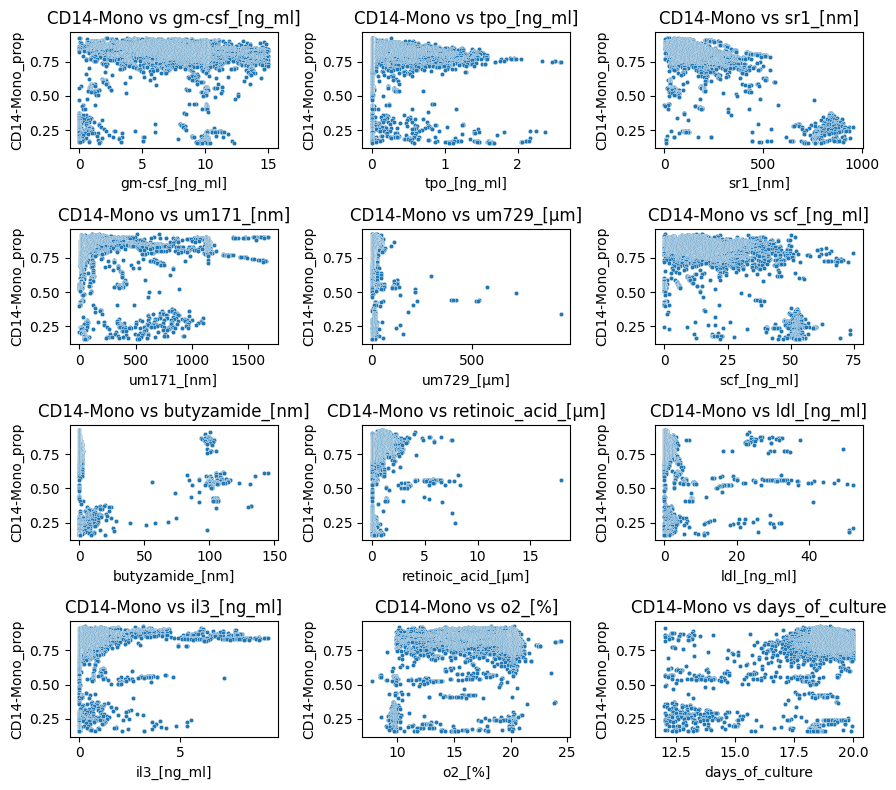

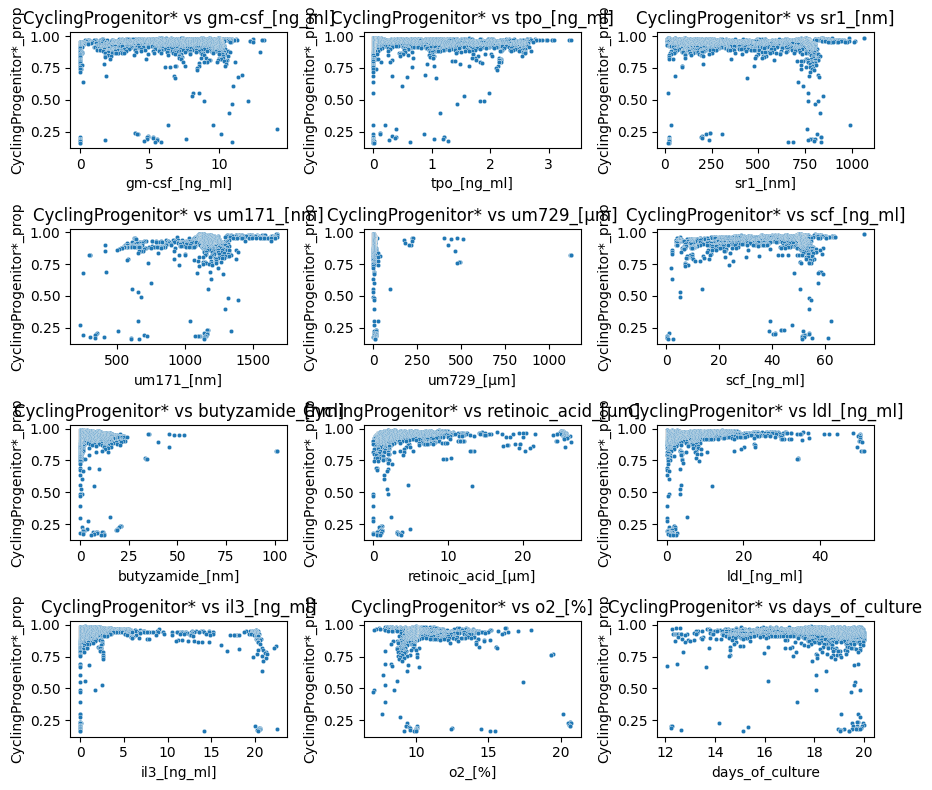

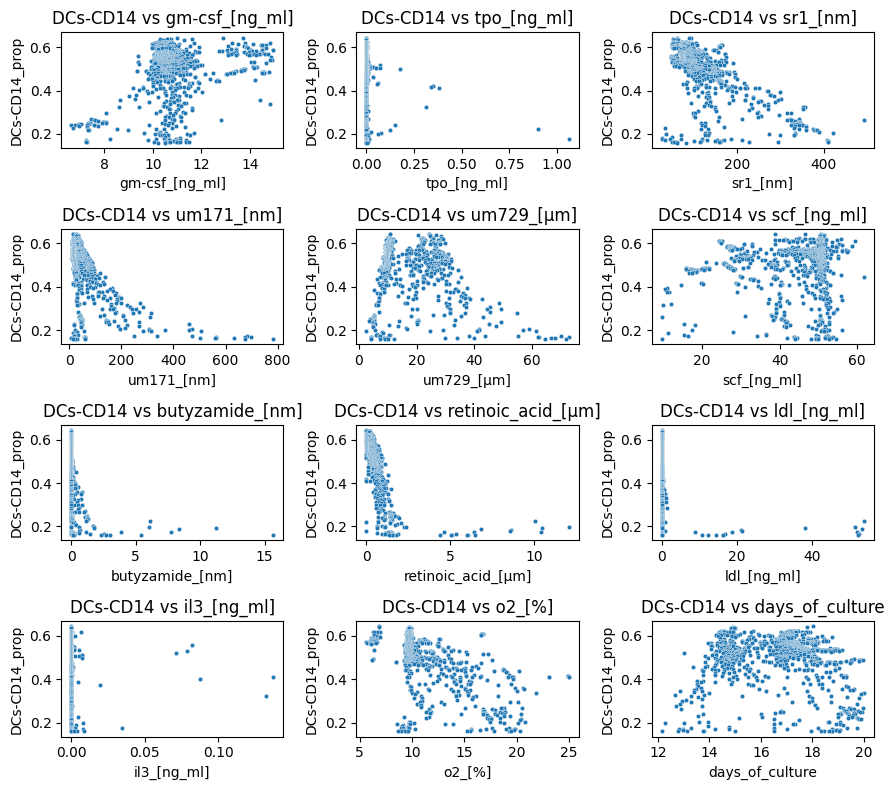

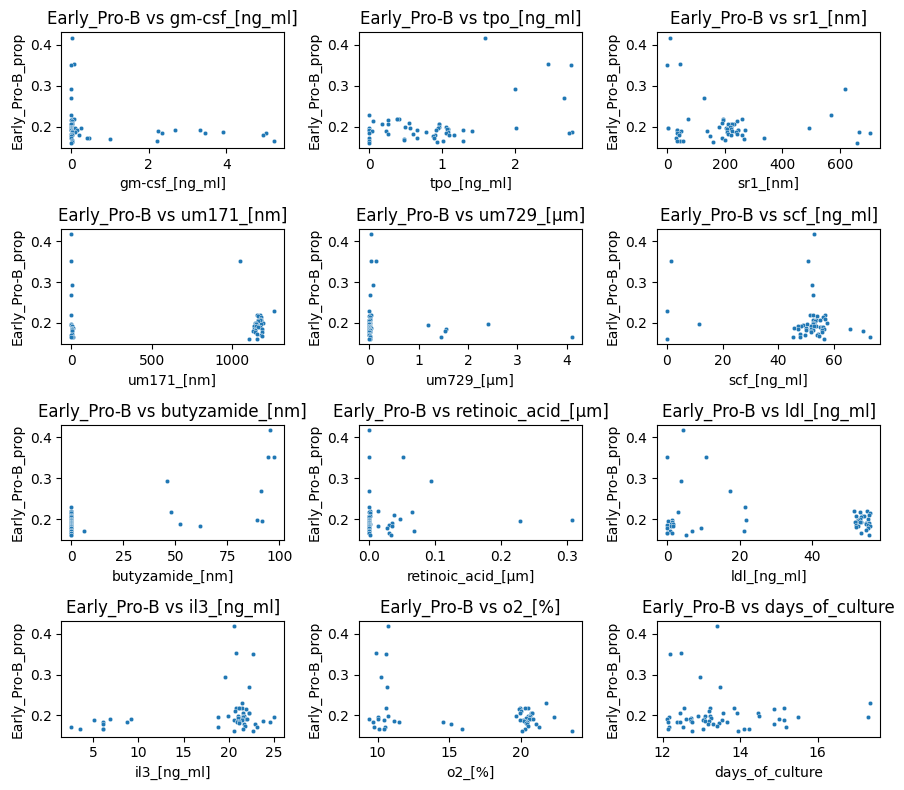

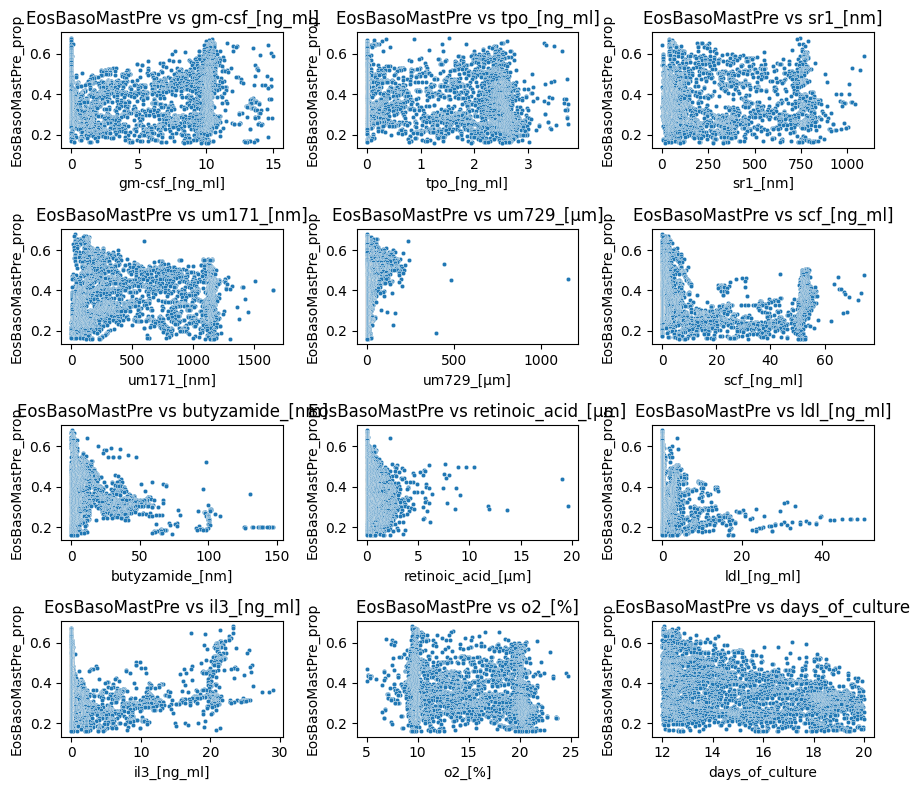

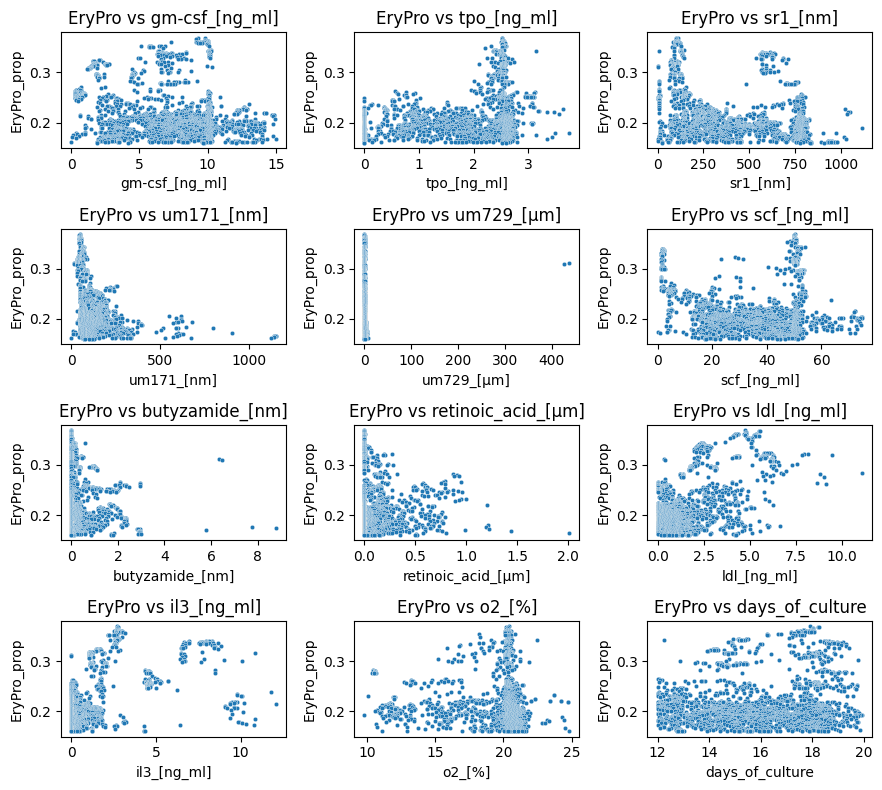

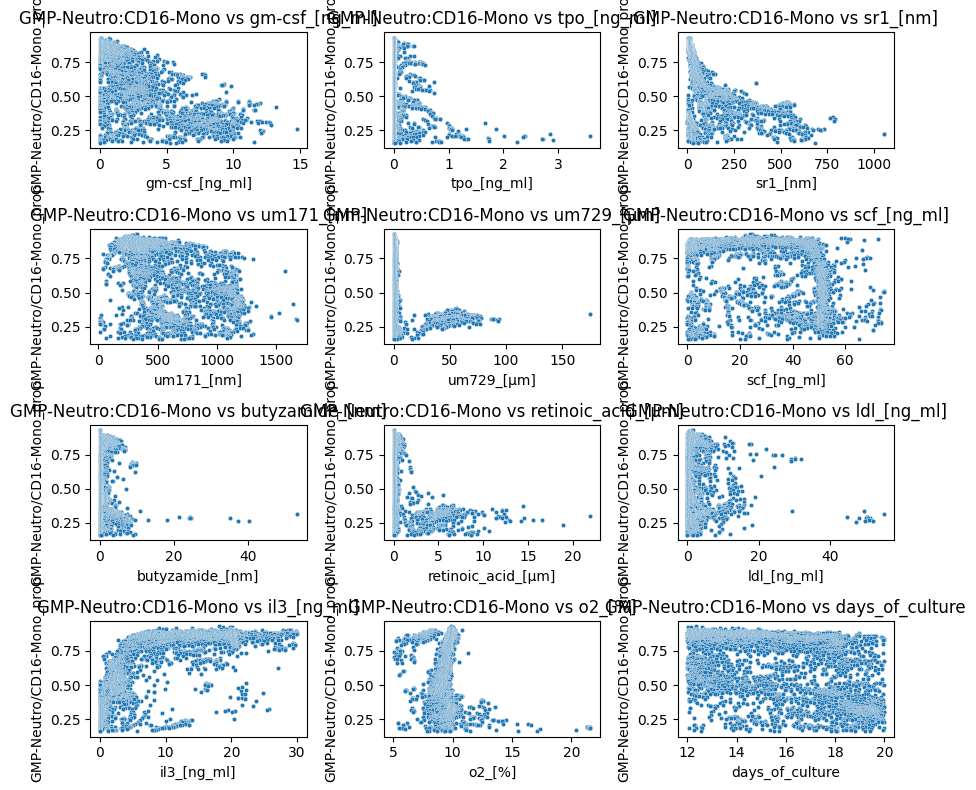

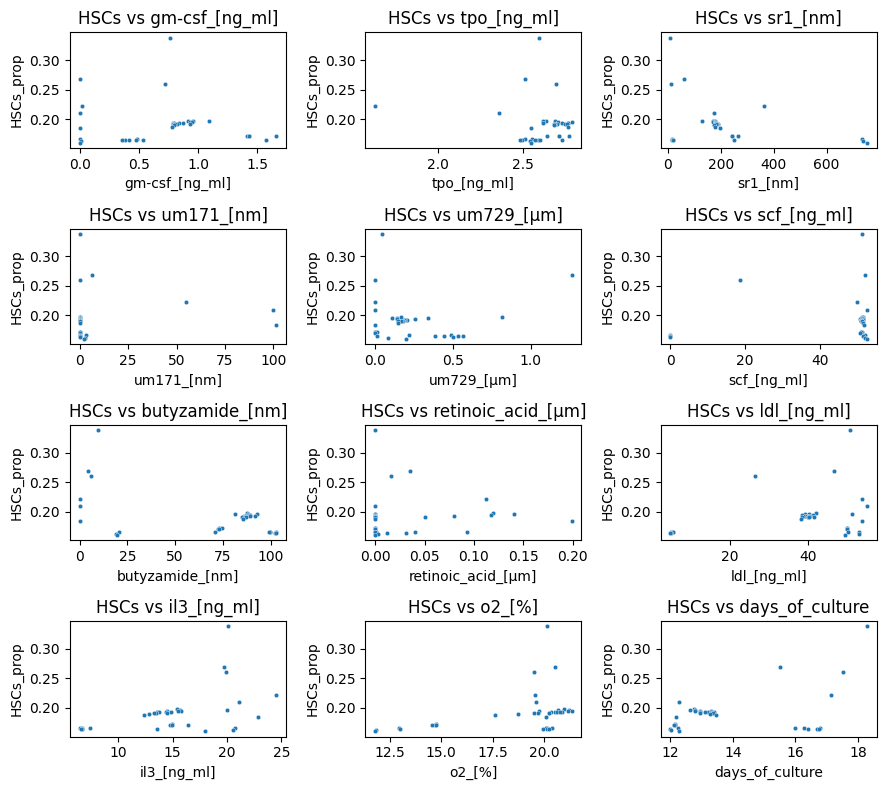

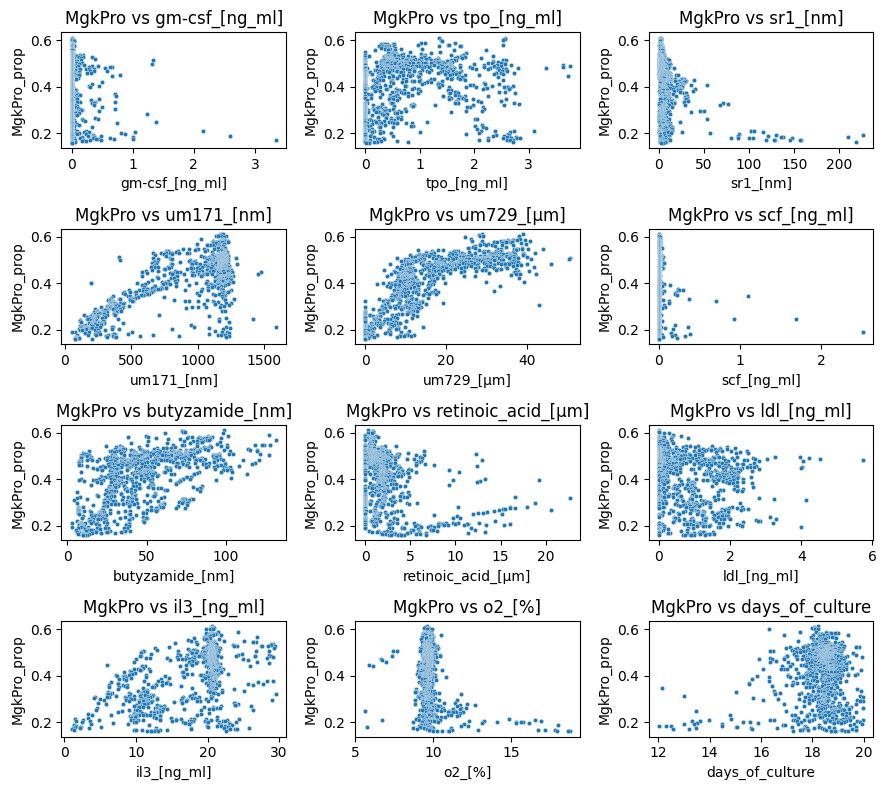

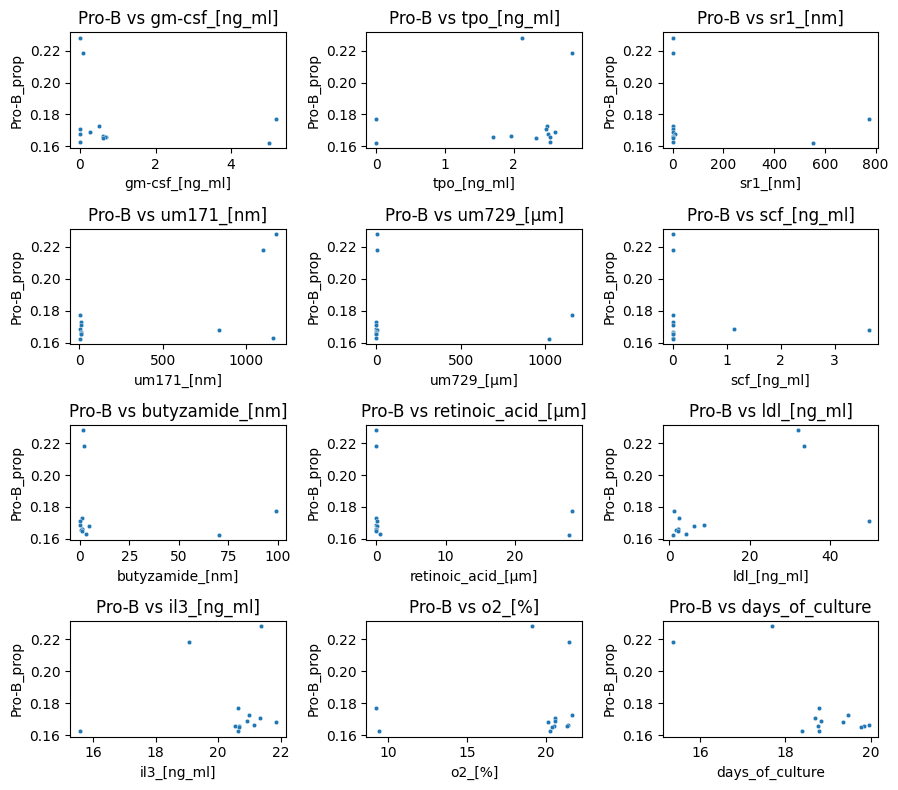

In [65]:
for cell_type in filtered_df:
    # Cell type safe
    cell_type_safe = cell_type.replace(":", "/")
    
    n_params = len(protocol_cols)
    ncols = 3  # adjust as you like
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2*nrows))
    axes = axes.flatten()  # make indexing easy

    for i, param in enumerate(protocol_cols):
        sns.scatterplot(
            data=filtered_df[cell_type],
            x=param,
            y=f"{cell_type_safe}_prop",
            ax=axes[i], 
            s=10
        )
        axes[i].set_title(f"{cell_type} vs {param}")

    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## Check the calibration (loss vs loss_std)

In [71]:
annotated_df["CD14-Mono"].columns

Index(['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'o2_[%]', 'days_of_culture', 'run_name',
       'cfg:constraints:c_scheduler_kwargs:t_warmup',
       'cfg:constraints:c_scheduler_kwargs:vmin',
       'cfg:constraints:c_scheduler_kwargs:vmax', 'loss', 'target_ct_loss_std',
       'ct_prop_total_variance', 'exploitation_score', 'CD14-Mono_prop',
       'filtering_step'],
      dtype='object')

<Axes: xlabel='CD14-Mono_prop', ylabel='target_ct_loss_std'>

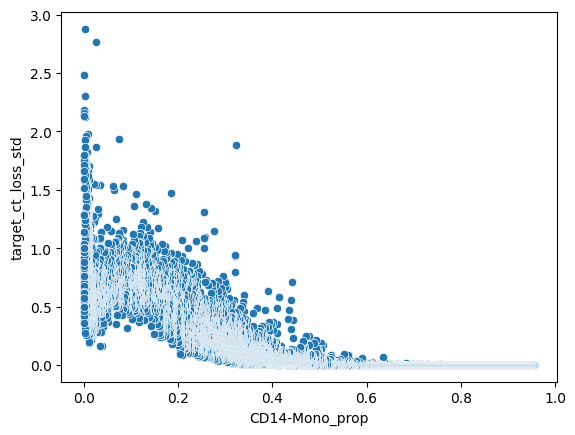

In [72]:
sns.scatterplot(data=annotated_df["CD14-Mono"], x="CD14-Mono_prop", y="target_ct_loss_std")

## Focus on MgkPro and similarity with Sakurai 

In [71]:
path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge"

In [72]:
sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

In [73]:
dict(zip(protocol_cols, sakurai_medium))

{'gm-csf_[ng_ml]': np.int64(0),
 'tpo_[ng_ml]': np.int64(0),
 'sr1_[nm]': np.int64(0),
 'um171_[nm]': np.int64(70),
 'um729_[µm]': np.int64(0),
 'scf_[ng_ml]': np.int64(0),
 'butyzamide_[nm]': np.int64(100),
 'retinoic_acid_[µm]': np.int64(0),
 'ldl_[ng_ml]': np.int64(0),
 'il3_[ng_ml]': np.int64(0),
 'o2_[%]': np.int64(20),
 'days_of_culture': np.int64(14)}

In [74]:
MgkPro_df = filtered_df["MgkPro"]

In [75]:
dist_mgkpro_sakurai = np.abs(MgkPro_df.loc[:, protocol_cols].values - sakurai_medium[None, :]).sum(1)

In [76]:
np.argmin(dist_mgkpro_sakurai)

np.int64(1132)

In [77]:
MgkPro_df.iloc[979]

gm-csf_[ng_ml]                                                                          0.0
tpo_[ng_ml]                                                                         0.23704
sr1_[nm]                                                                           7.745216
um171_[nm]                                                                        244.63007
um729_[µm]                                                                         8.079868
scf_[ng_ml]                                                                             0.0
butyzamide_[nm]                                                                    50.41478
retinoic_acid_[µm]                                                                      0.0
ldl_[ng_ml]                                                                        0.334242
il3_[ng_ml]                                                                        9.804232
o2_[%]                                                                          

In [78]:
distances_from_sakurai_per_cell_type = {}

for cell_type in filtered_df:
    df_cell_type = filtered_df[cell_type]
    distances_from_sakurai_per_cell_type[cell_type] = np.abs(df_cell_type.loc[:, protocol_cols].values - sakurai_medium[None, :]).sum(1)

52.13490686


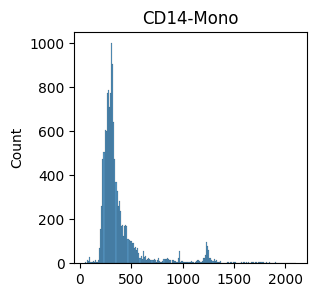

404.50443893000005


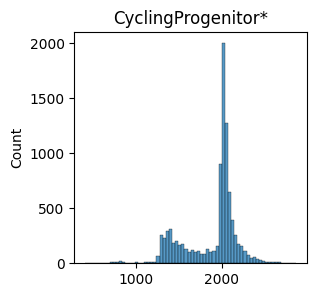

267.56477292115596


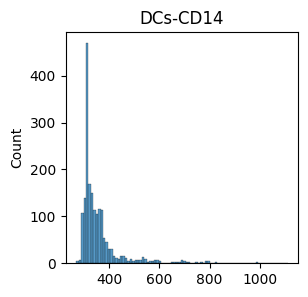

163.57174612


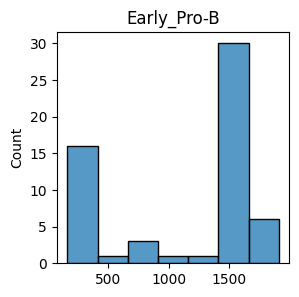

79.13640380349999


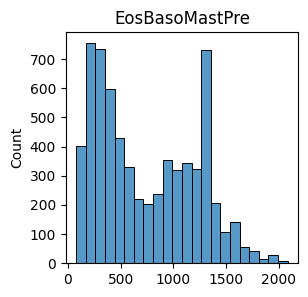

179.28297652999996


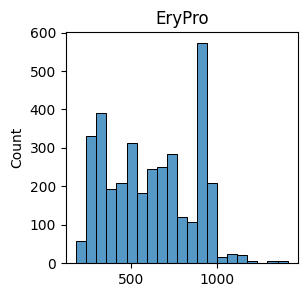

144.68513857


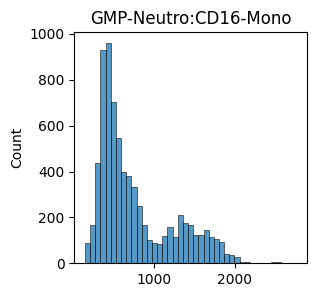

104.4845766734


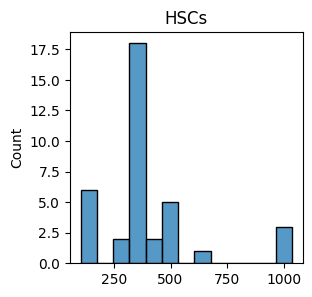

119.03860253599998


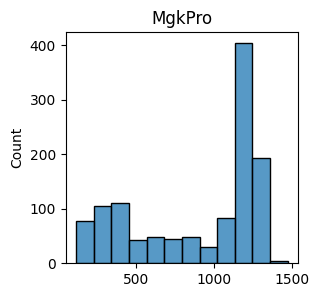

192.54778952


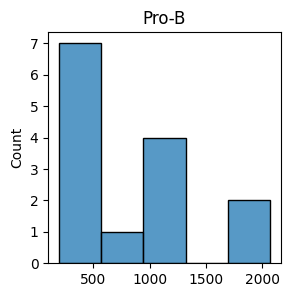

In [79]:
for cell_type in distances_from_sakurai_per_cell_type:
    plt.figure(figsize=(3,3))
    sns.histplot(distances_from_sakurai_per_cell_type[cell_type])
    print(np.min(distances_from_sakurai_per_cell_type[cell_type]))
    plt.title(cell_type)
    plt.show()

## Check uncertainties at every filtering step 

In [80]:
# def annotate_filtering_steps(): 

In [81]:
# for cell_type in pure_cell_type_solution_dict_concat:
#     cell_type_safe = cell_type.replace(":", "/")

#     df_plot = pure_cell_type_solution_dict_concat[cell_type].reset_index(drop=True)

#     plt.figure(figsize=(2,2))
#     sns.scatterplot(
#         data=df_plot,
#         x=f"{cell_type_safe}_prop",
#         y="target_ct_loss_std",
#         edgecolor="black"
#     )
#     plt.show()

## Compare uncertainty of solutions that make the cut 

In [82]:
# for cell_type in annotated_df:

#     df_plot = annotated_df[cell_type].reset_index(drop=True)

#     plt.figure(figsize=(2.8, 3.2))

#     ax = sns.boxplot(
#         data=df_plot,
#         x="filtering_step",
#         y="target_ct_loss_std",
#         hue="filtering_step", 
#         order=["proportion_filter", "oxygen_days", "bounds", "pass"],
#         width=0.6,
#         fliersize=1,
#         palette="colorblind"
#     )

#     # Clean aesthetics
#     sns.despine()
#     ax.set_xlabel("")
#     ax.set_ylabel("Target CT loss (std)")
#     ax.set_title(cell_type, fontsize=10)

#     plt.xticks(rotation=90, ha="right")
#     plt.tight_layout()
#     plt.show()

TODO:
* Compare with Sakurai
* Same analysis with custom (HSCs, MgkPro, EryPro)
* Uncertainty calibration 

In [83]:
annotated_df["Early_Pro-B"]["filtering_step"].value_counts()

filtering_step
proportion_filter        38175
oxygen_days               4867
pass                        58
bounds_sr1_[nm]             50
bounds_tpo_[ng_ml]          19
bounds_um171_[nm]           17
bounds_gm-csf_[ng_ml]        9
bounds_scf_[ng_ml]           5
Name: count, dtype: int64

In [84]:
annotated_df["HSCs"]["filtering_step"].value_counts()

filtering_step
proportion_filter         31312
oxygen_days                1034
bounds_gm-csf_[ng_ml]       435
bounds_tpo_[ng_ml]          166
bounds_sr1_[nm]             110
pass                         37
bounds_butyzamide_[nm]        5
bounds_scf_[ng_ml]            1
Name: count, dtype: int64

In [85]:
annotated_df["Early_Pro-B"].max(0)

gm-csf_[ng_ml]                                                                  4730.371
tpo_[ng_ml]                                                                      71021.4
sr1_[nm]                                                               244782110000000.0
um171_[nm]                                                                   662204350.0
um729_[µm]                                                                 11397916000.0
scf_[ng_ml]                                                                41133560000.0
butyzamide_[nm]                                                               17149444.0
retinoic_acid_[µm]                                                              50.57831
ldl_[ng_ml]                                                                    1028.4215
il3_[ng_ml]                                                                    5468.6445
o2_[%]                                                                         1540.3678
days_of_culture      

In [86]:
bounds

{'gm-csf_[ng_ml]': (0.0, 10.0),
 'tpo_[ng_ml]': (0.0, 2.5),
 'um171_[nm]': (0.0, 1120.0),
 'um729_[µm]': (0.0, 1120.0),
 'sr1_[nm]': (0.0, 750.0),
 'scf_[ng_ml]': (0.0, 50.0),
 'butyzamide_[nm]': (0.0, 100.0),
 'retinoic_acid_[µm]': (0.0, 25.0),
 'ldl_[ng_ml]': (0.0, 50.0),
 'il3_[ng_ml]': (0.0, 20.0),
 'o2_[%]': (10.0, 20.0),
 'days_of_culture': (12.0, 18.0)}

In [87]:
for t_warmup, vmin, vmax in zip(filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 1.0
t_warmup: 0.1 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 1.0
t_warmup: 0.0 vmin: 10.0 vm

In [88]:
for t_warmup, vmin, vmax in zip(filtered_df["HSCs"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["HSCs"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.1 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 15.0 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.0 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.0 vmin: 15.0 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 1.0
t_warmup: 0.25 vmin: 

In [89]:
for t_warmup, vmin, vmax in zip(filtered_df["Pro-B"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.0 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 2.0
t_warmup: 0.0 vmin: 10.0 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 1.0


In [90]:
for t_warmup, vmin, vmax in zip(filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.1 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.0 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 15.0 vmax: 1.0
t_warmup: 0.0 vmin: 15.0 vmax: 5.0
t_warmup: 0.0 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 1.0
t_warmup: 0.0 vmin: 15.0 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 1.0
t_warmup: 0.5 vmin: 7.5 vmax: 1.0
t_warmup: 0.1 vmin: 10.0 vmax: 1.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.1 vmin: 10.0 vmax: 2.0
t_warmup: 0.0 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 2.0
t_warmup: 0.1 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin:

In [91]:
filtered_df["EryPro"]["run_name"].value_counts()

run_name
penalized_all_axes-pure_populations-constant      2128
penalized_all_axes-pure_populations-reciprocal     717
penalized_oxy_days-pure_populations-constant       431
penalized_oxy_days-pure_populations-reciprocal     253
unconstrained-pure_populations-reciprocal           10
unconstrained-pure_populations-constant              8
Name: count, dtype: int64

In [96]:
filtered_df["EryPro"][filtered_df["EryPro"]["EryPro_prop"]>0.40].loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
95,2.811382,0.0,101.41675,0.086865,0.00538,0.0,22.873796,0.019207,0.0,0.886919,22.784748,19.671104
95,2.537652,0.0,91.03853,0.305333,0.00000,0.0,22.148872,0.000000,0.0,0.940211,22.934235,18.980879


## Check values of penalization parameters

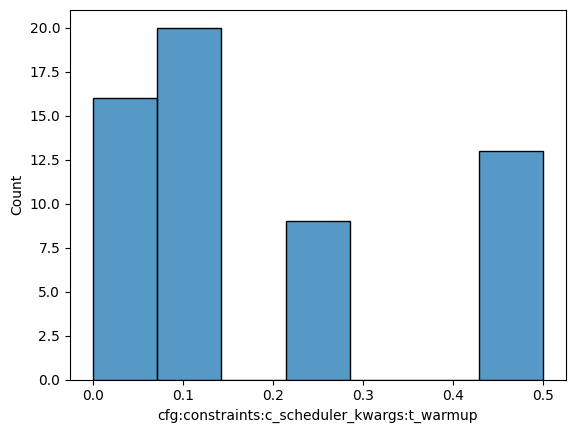

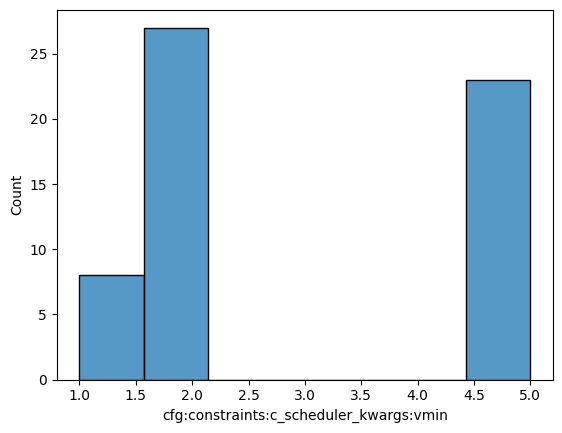

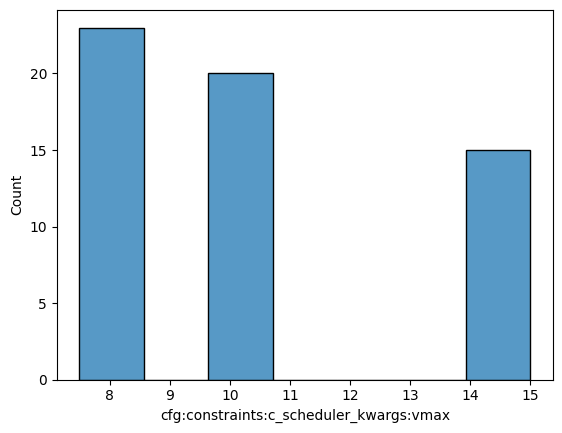

In [93]:
sns.histplot(data=filtered_df["Early_Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:t_warmup")
plt.show()

sns.histplot(data=filtered_df["Early_Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmin")
plt.show()

sns.histplot(data=filtered_df["Early_Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmax")
plt.show()

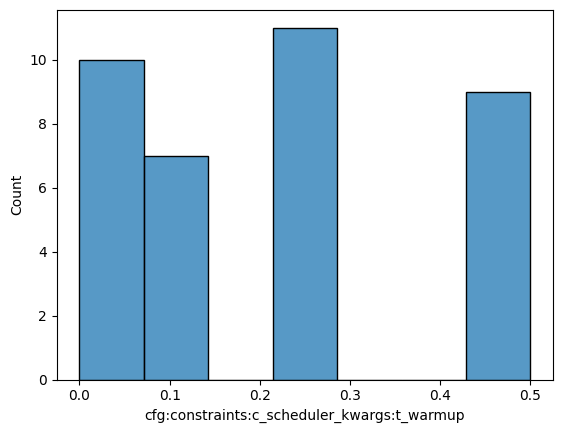

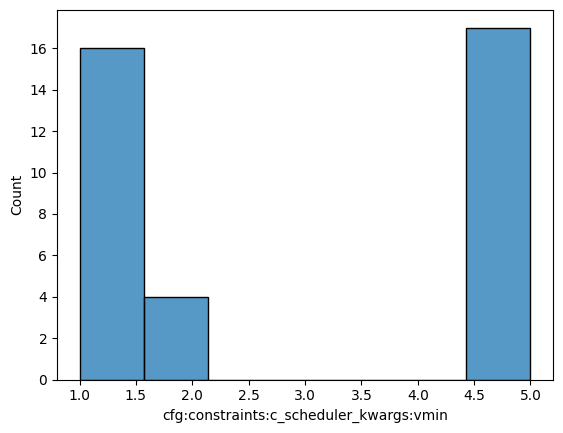

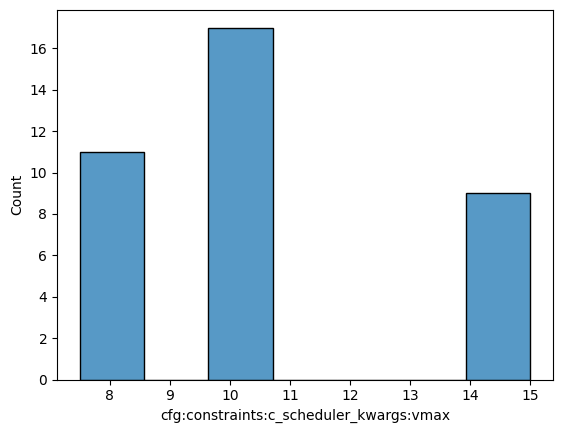

In [94]:
sns.histplot(data=filtered_df["HSCs"],
             x="cfg:constraints:c_scheduler_kwargs:t_warmup")
plt.show()

sns.histplot(data=filtered_df["HSCs"],
             x="cfg:constraints:c_scheduler_kwargs:vmin")
plt.show()

sns.histplot(data=filtered_df["HSCs"],
             x="cfg:constraints:c_scheduler_kwargs:vmax")
plt.show()

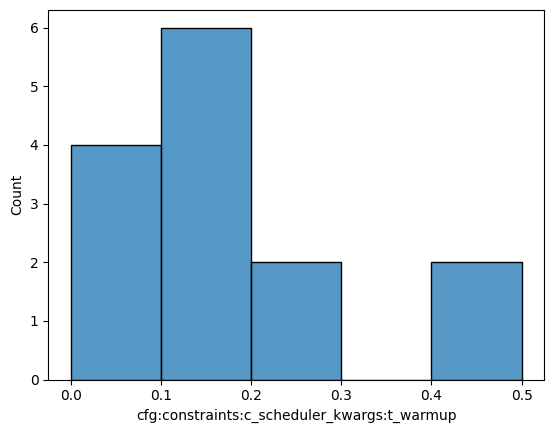

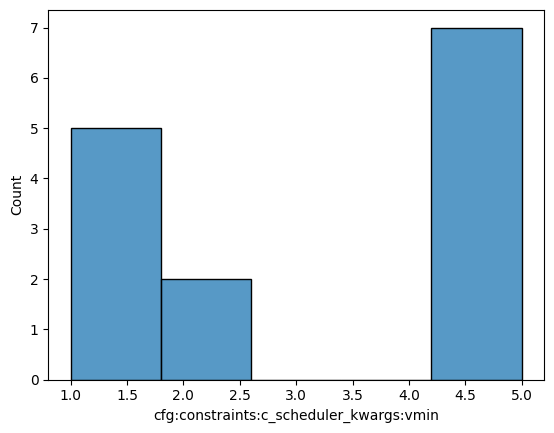

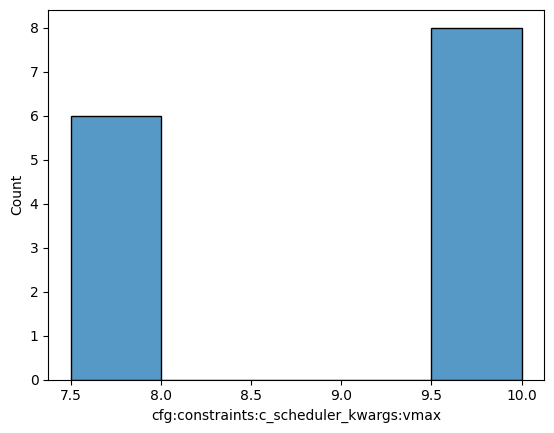

In [95]:
sns.histplot(data=filtered_df["Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:t_warmup")
plt.show()

sns.histplot(data=filtered_df["Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmin")
plt.show()

sns.histplot(data=filtered_df["Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmax")
plt.show()

## Check HSCs

In [141]:
hsc = annotated_df["HSCs"]

In [142]:
hsc = hsc[hsc["HSCs_prop"]>0.20]

In [144]:
hsc["HSCs_prop"]

1     0.986106
1     0.982787
1     0.970116
1     0.966858
1     0.962938
        ...   
57    0.201281
57    0.201232
57    0.200965
57    0.200707
23    0.200661
Name: HSCs_prop, Length: 1416, dtype: float64

In [145]:
hsc

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,run_name,cfg:constraints:c_scheduler_kwargs:t_warmup,cfg:constraints:c_scheduler_kwargs:vmin,cfg:constraints:c_scheduler_kwargs:vmax,HSCs_prop,filtering_step
1,6.569984,0.000000,153632.8600,6.714414e+07,0.0,211.43658,0.000000,2.661355,0.000000,2.828494,10.163538,18.056280,penalized_oxy_days-pure_populations-constant,0.00,1.0,10.0,0.986106,bounds_sr1_[nm]
1,5.891402,0.000000,104412.0900,4.141446e+07,0.0,475.35320,0.000000,2.945220,0.000000,1.782627,9.359149,14.456262,penalized_oxy_days-pure_populations-constant,0.00,0.0,1.0,0.982787,bounds_sr1_[nm]
1,14.258337,0.121066,72342.3300,7.071313e+06,0.0,269.67215,0.000000,2.066390,0.000000,1.791845,11.573683,18.057867,penalized_oxy_days-pure_populations-constant,0.10,5.0,10.0,0.970116,bounds_sr1_[nm]
1,15.341749,0.000000,29160.9650,1.265267e+08,0.0,114.44228,0.000000,4.837924,0.000000,0.000000,9.984079,18.040218,penalized_oxy_days-pure_populations-constant,0.50,5.0,15.0,0.966858,bounds_gm-csf_[ng_ml]
1,14.479015,0.305590,58790.8300,4.875003e+06,0.0,299.94320,0.000000,2.226908,0.000000,1.614382,11.732524,18.062057,penalized_oxy_days-pure_populations-constant,0.25,2.0,10.0,0.962938,bounds_sr1_[nm]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,3.218938,6.753418,1436.7832,0.000000e+00,0.0,2381.72140,76.550900,0.000000,19.624820,2.077442,10.107030,12.091349,penalized_oxy_days-pure_populations-constant,0.25,2.0,10.0,0.201281,bounds_tpo_[ng_ml]
57,3.244003,6.448870,1402.3411,0.000000e+00,0.0,2304.63000,78.297010,0.000000,19.327183,1.936353,9.738696,11.715872,penalized_oxy_days-pure_populations-constant,0.00,2.0,15.0,0.201232,oxygen_days
57,3.206873,6.324453,1320.3856,4.748948e-02,0.0,2096.40100,70.702580,0.034063,18.973011,1.951718,9.897656,11.839190,penalized_oxy_days-pure_populations-constant,0.10,5.0,10.0,0.200965,oxygen_days
57,3.211532,6.316972,1331.1400,0.000000e+00,0.0,2226.86380,73.020650,0.000000,18.903944,1.953685,10.174547,12.125824,penalized_oxy_days-pure_populations-constant,0.10,5.0,15.0,0.200707,bounds_tpo_[ng_ml]


In [131]:
annotated_df["HSCs"]["filtering_step"].value_counts()

filtering_step
proportion_filter         31312
oxygen_days                1034
bounds_gm-csf_[ng_ml]       435
bounds_tpo_[ng_ml]          166
bounds_sr1_[nm]             110
pass                         37
bounds_butyzamide_[nm]        5
bounds_scf_[ng_ml]            1
Name: count, dtype: int64

(array([3.3045e+04, 3.1000e+01, 1.5000e+01, 0.0000e+00, 3.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([   0.      ,  150.323526,  300.647052,  450.970578,  601.294104,
         751.61763 ,  901.941156, 1052.264682, 1202.588208, 1352.911734,
        1503.23526 , 1653.558786, 1803.882312, 1954.205838, 2104.529364,
        2254.85289 , 2405.176416, 2555.499942, 2705.823468, 2856.146994,
        3006.47052 , 3156.

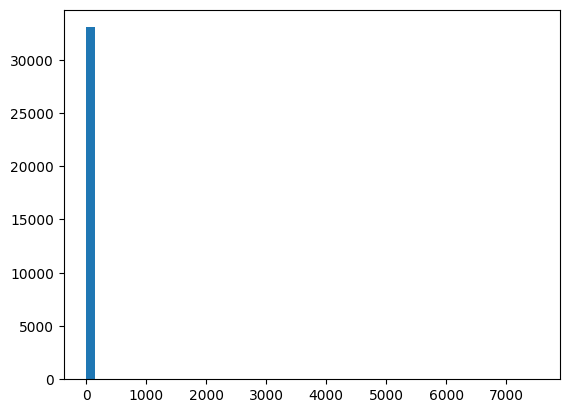

In [140]:
plt.hist(annotated_df["HSCs"]["o2_[%]"], 50)